# CPSC 488/588 - Homework 3 - Diffusion Models
### Yale University - AI Foundation Models Course

*Instructor: Arman Cohan*

---

This homework helps you implement a Denoising Diffusion Probabilistic Model (DDPM).  
For references please refer to the original [DDPM paper](https://arxiv.org/pdf/2006.11239.pdf).

In this homework you need to complete the notebook and run all the cells.
We have specified the parts to be completed with `TODO` tags inside the code blocks.

*NOTE*: It is important that you read all the code and text blocks carefully, even if you think you are excited to jump into completing the missing codes.

In [51]:
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision
import math
import matplotlib.pyplot as plt
import torch
import urllib
import numpy as np
from tqdm import tqdm
import PIL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [78]:
# The images that we read are in PIL format (through numpy library)
# We first want to use some functionality to be able to work with images
# The first thing we want to do is apply some transforms into a raw image
# This includes resizing them into 32 by 32, converting them into a tensor and
# scaling the values to be between -1 to 1 instead of 0 to 1

transform = transforms.Compose( # PIL -> torch
    [
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
            # by default our image is scaled from 0 to 1, but we need it to be from -1 to 1
            # use a Lambda transform to scale the image
        transforms.Lambda(lambda t: (t*2) - 1)
    ]
)

# We also need the reverse of this transform to go from pytorch tensors to PIL images
# We define a series of reverse transforms here

reverse_transform = transforms.Compose([
    transforms.Lambda(lambda t: (t + 1) / 2),
    transforms.Lambda(lambda t: t.permute(1, 2, 0)),
    transforms.Lambda(lambda t: t * 255.0),
    transforms.Lambda(lambda t: t.clamp(0, 255).numpy().astype(np.uint8)),
    transforms.ToPILImage(),
])

# First let's get a sample image
# This is a toy sampler that samples a dog or a cat from wikimedia

def get_sample_image(object="dog")-> PIL.Image.Image:
    if object == "dog":
        url = 'https://upload.wikimedia.org/wikipedia/commons/f/fa/Dog-2016-11-b.jpg'
        filename = 'dog.jpg'
    elif object == "cat":
        url = 'https://upload.wikimedia.org/wikipedia/commons/e/e5/Blue-eyed_domestic_cat_%28Felis_silvestris_catus%29.jpg '
        filename = 'cat.jpg'
    else:
        raise NotImplementedError("Invalid object")
    urllib.request.urlretrieve(url, filename)
    raw_image = PIL.Image.open(filename)
    return raw_image

In [53]:
# These are some utility functions to plot noise distributions
# You don't need to worry about these at this point

def plot_noise_distribution(noise, predicted_noise):
    plt.hist(noise.cpu().numpy().flatten(), density = True, alpha = 0.8, label = "ground truth noise")
    plt.hist(predicted_noise.cpu().numpy().flatten(), density = True, alpha = 0.8, label = "predicted noise")
    plt.legend()
    plt.show()

def plot_noise_prediction(noise, predicted_noise):
    plt.figure(figsize=(15,15))
    f, ax = plt.subplots(1, 2, figsize = (5,5))
    ax[0].imshow(reverse_transform(noise.cpu()))
    ax[0].set_title(f"ground truth noise", fontsize = 10)
    ax[1].imshow(reverse_transform(predicted_noise.cpu()))
    ax[1].set_title(f"predicted noise", fontsize = 10)
    plt.show()

# Part 1: Implementing the forward diffusion process  

### Background

Recall that the in diffusion forward process given a data point sampled from a data distribution $ x_0 \sim q(x) $, we want to get a noisy image at step $T$. In particular, the forward diffusion process adds a small amount of Gaussian noise to the sample in $ T $ steps and produces a sequence of noisy samples $ x_1, \ldots, x_T $. The forward diffusion process is controlled by a variance schedule $ \{\beta_t \in (0, 1)\}^T_{t=1} $.

$$ q(x_t|x_{t-1}) = N(x_t; \sqrt{1 - \beta_t}x_{t-1}, \beta_t\mathbf{I}) $$

$$ q(x_{1:T}|x_0) = \prod_{t=1}^T q(x_t|x_{t-1}) $$

The sampled image $ x_0 $ gradually becomes noisier as the step $ t $ becomes larger. Eventually when $ T \rightarrow \infty $, $ x_T $ is equivalent to an isotropic Gaussian distribution. This is a markov process and we can apply the above formulation $T$ times to get to a noisy image at timestep $T$. However, this process is slow and expensive. Fortunately this is not necessary!


Recall that we can sample $x_t$ at any timestep $t$ **directly** using the reparametarization trick.  
Let $\alpha_t = 1-\beta_t$ and $\hat{\alpha}_t = \prod_{i=1}^t \alpha_i$.  
Then  
$ q(x_t|x_0) = N(x_t; \sqrt{\hat{\alpha}_t}x_0, (1 - \hat{\alpha}_t)\mathbf{I})$  

---

## Given this background fill out the missing parts in the code below
These are specified with TODO items

In [54]:
# let's assume an input that has batch size of 2, 3 channels, and 32x32 image resolution
x0 = torch.randn(2, 3, 32, 32).to(device)

In [55]:
# let's define our betas
betas = torch.tensor([0.05, 0.1, 0.15, 0.2, 0.25]).to(device)

In [56]:
# let's define our timesteps
# this will be a specific timestep for each image in the batch
# therefore the batch dimension of t and x0 must be the same
t = torch.tensor([1, 3]).to(device)
t

tensor([1, 3], device='cuda:0')

In [57]:
# now we want to get the value a_hat_t
# betas -> amounts of noise that are being applied to every timestep of the diffusion process
# alphas -> 1- betas -> amount of the original image that is being preserved at every timestep of the diffusion process

# TODO: complete
alphas = 1 - betas


In [58]:
# alpha_bar is the comumulative product of alphas

# TODO: complete
alpha_bar = torch.cumprod(alphas, dim=0)

In [59]:
print(betas)
print(alphas)
print(alpha_bar)

tensor([0.0500, 0.1000, 0.1500, 0.2000, 0.2500], device='cuda:0')
tensor([0.9500, 0.9000, 0.8500, 0.8000, 0.7500], device='cuda:0')
tensor([0.9500, 0.8550, 0.7267, 0.5814, 0.4360], device='cuda:0')


In [60]:
# Some pytorch stuff
# we want to select values of alpha_bar that correspond to the timesteps
# That is for each element in the batch, we want to select the corresponding timestep

result = alpha_bar.gather(-1, t)
# hint the result shape should be [2]

In [61]:
# now check the above equation and the description of the diffusion process again
# we want to add information from alpha_bar to x_0 (by multiplying them)
# alpha_bar intuitively shows how much of the original image we are preserving
# In order to do the multiplication we need to reshape the `result` tensor so that it has the same shape as x_0 in the batch dimension
# hint use reshape

# TODO: complete
result = result.reshape(x0.shape[0], 1, 1, 1)

In [62]:
# now let's do the multiplication

# let's sample some noise
torch.manual_seed(0)
noise = torch.randn_like(x0)

# then let's get the mean of the distribution
# check out the formula above for the mean and variance of the image at timestep t given original image x_0
# Note that standard deviation is the square root of the variance

# TODO: complete
mean = result.sqrt() * x0
variance = (1 - result).sqrt() * noise
x_t = mean + variance

Ok that's all!
But now let's actually make this more systematic and write a function that does the diffusion process for us.

Again whereever you see TODO complete that part

In [63]:
def forward_diffusion(x_0, t, betas):
    """
    x_0: input image of shape (batch_size, channels, height, width)
    t: timesteps of shape (batch_size)
    """
    noise = torch.randn_like(x_0, device=x_0.device)
    alphas = 1 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    alpha_bar_at_timestep = alpha_bar.gather(-1, t)
    alpha_bar_at_timestep = alpha_bar_at_timestep.reshape(t.shape[0], 1, 1, 1)
    mean = alpha_bar_at_timestep.sqrt() * x_0
    variance = (1 - alpha_bar_at_timestep).sqrt() * noise
    return mean + variance, noise

So far we've seen how to work with a randomly generated image.  
Now let's work with a real image file!

Let's sample a dog and a cat photo, run them through the diffusion process and visualize the forward process.

In [64]:
import torchvision.datasets as datasets

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
TARGET_CLASS      = 1   # automobile
TARGET_CLASS_NAME = CIFAR10_CLASSES[TARGET_CLASS]

# Full dataset with transforms (for training)
full_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
class_indices = [i for i, (_, label) in enumerate(full_dataset) if label == TARGET_CLASS]
subset = torch.utils.data.Subset(full_dataset, class_indices)
print(f"Training images: {len(subset)}")  # should be 5000

# Raw dataset without transforms (for cat/dog PIL images the prof's cells need)
raw_dataset = datasets.CIFAR10(root="./data", train=True, download=False)
cat_indices = [i for i, (_, l) in enumerate(raw_dataset) if l == 3]
dog_indices = [i for i, (_, l) in enumerate(raw_dataset) if l == 5]
cat_image = raw_dataset[cat_indices[0]][0]
dog_image = raw_dataset[dog_indices[0]][0]

cat_torch_img = transform(cat_image)
dog_torch_img = transform(dog_image)
print(f"cat_torch_img shape: {cat_torch_img.shape}")

Training images: 5000
cat_torch_img shape: torch.Size([3, 32, 32])


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [65]:
# OK, these are numpy PIL images
# we want to convert them to torch tensors so we can work with them
# recall the utility functions that we described above.
# they will be handy here.
# let's do the transformation and watch the shape

cat_torch_img = transform(cat_image)
dog_torch_img = transform(dog_image)
cat_torch_img.shape

torch.Size([3, 32, 32])

Text(0.5, 1.0, 'dog')

<Figure size 1500x1500 with 0 Axes>

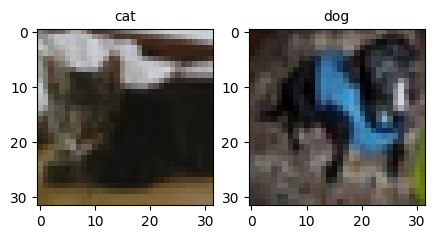

In [66]:
# we want to also make sure that we can go back from tensors to PIL images to visualize stuff
# so we test the reverse_transform as well

pil_cat_image = reverse_transform(cat_torch_img)
pil_dog_image = reverse_transform(dog_torch_img)

# let's define a matplotlib grid that visualizes these
plt.figure(figsize=(15,15))
f, ax = plt.subplots(1, 2, figsize = (5,5))
ax[0].imshow(pil_cat_image)
ax[0].set_title(f"cat", fontsize = 10)
ax[1].imshow(pil_dog_image)
ax[1].set_title(f"dog", fontsize = 10)

**Note**

At this point after running these, you should see a 1x2 grid that shows both of the images in a small size (and low 32x32 resolution).

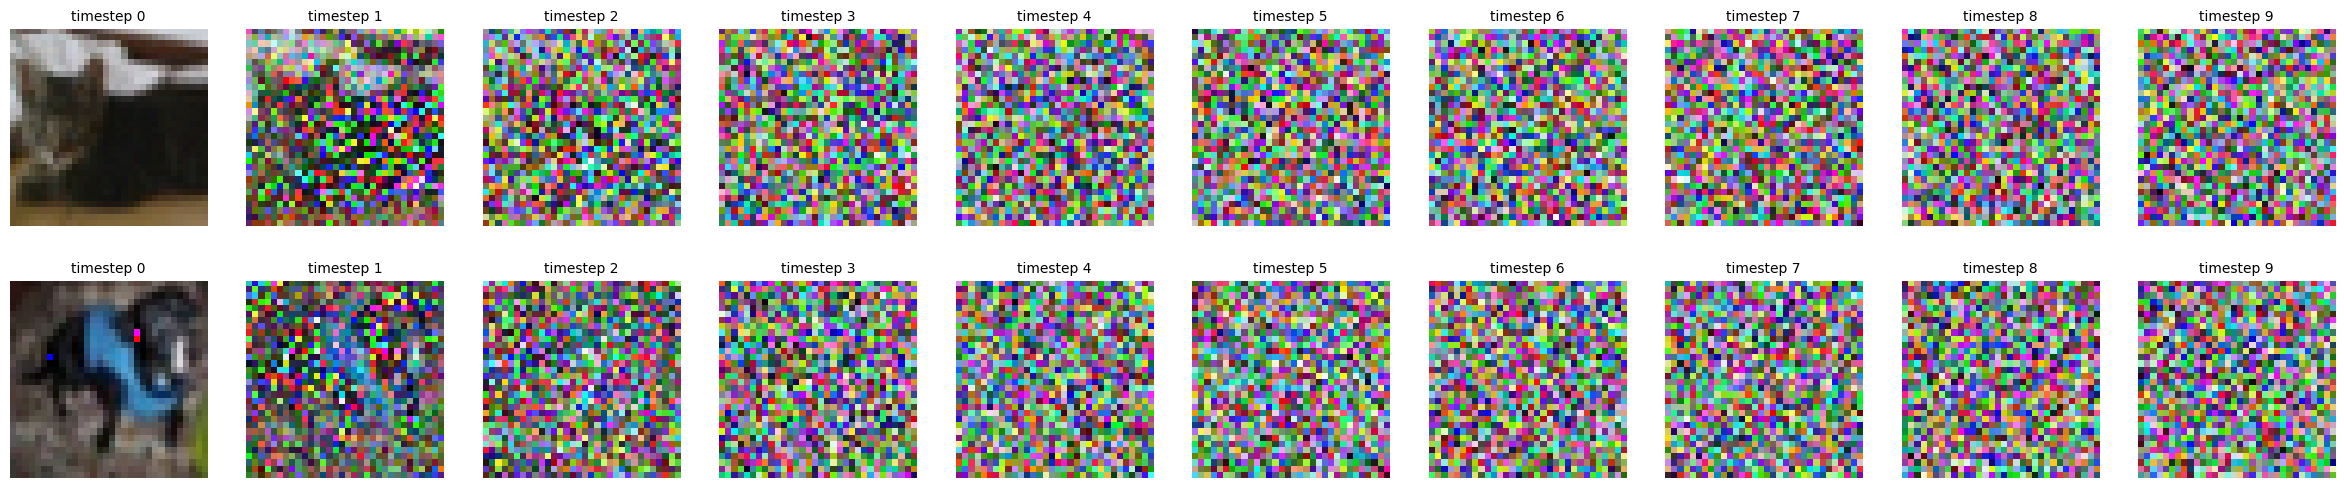

In [67]:
# let's first create a mini-batch that has a cat and a dog image
x0 = torch.stack([cat_torch_img, dog_torch_img], dim = 0).to(device)

# recall our beta values,
# it is usually a linear noise schedule with T values
# therefore our markov process has T timesteps
# for every timestep we want to see how the image looks like as we add more noise to it
# we will visualize it in a grid

start_schedule=0.0001
end_schedule=1
timesteps=10
betas = torch.linspace(start_schedule, end_schedule, timesteps, device=device)

# Let's use our implementation of the forward_diffusion function above

f, axs = plt.subplots(2, timesteps, figsize = (timesteps*3,6))
# for each timestep we run the forward process, get the noisy image and visualize it
for i in range(timesteps):
    timestep = torch.tensor([i, i]).to(device)
    noisy_images, noise = forward_diffusion(x0, timestep, betas)
    for j, row in enumerate(axs):
        row[i].imshow(reverse_transform(noisy_images[j].cpu()))
        row[i].set_title(f"timestep {i}", fontsize = 10)
        row[i].axis("off")
plt.show()

You should see something like this.

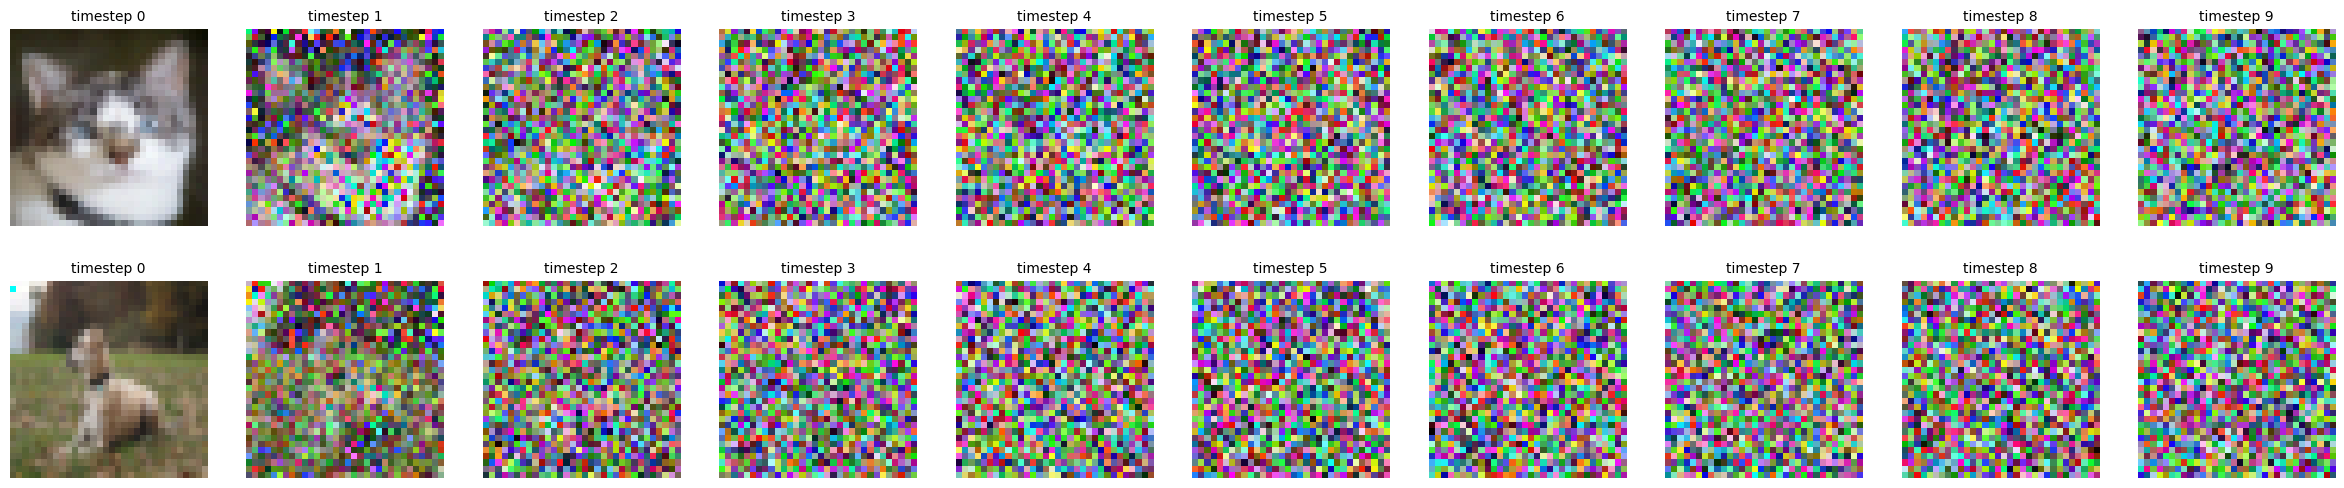

# Part 2: Implmeneting a DiffusionModel class

Ok so far we were able to implement a simple forward diffusion function.  
Now let's clean things up and actually turn this into a class.

As before, we will parts that you need to implement as TODO.

We use in line comments to guide you through the implmenetation.

In [68]:
class DiffusionModel:
    def __init__(self, start_schedule=0.0001, end_schedule=0.02, timesteps = 300, device="cpu") -> None:
        self.start_schedule = start_schedule
        self.end_schedule = end_schedule
        self.timesteps = timesteps

        self.betas = torch.linspace(start_schedule, end_schedule, timesteps, device=device)
        self.device = device

        # TODO: Complete
        self.alphas = 1 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)


    def forward(self, x_0, t, noise=None):
        """
        Runs the diffusion forward process
        x_0: input image of shape (batch_size, channels, height, width)
        t: timesteps of shape (batch_size)
        """
        if noise is None:
            noise = torch.randn_like(x_0, device=self.device)

        # TODO: Complete
        # You will need a few lines of code here
        # Refer to your implementation above
        # We have included a utility function in the class called `self.get_index_from_list`
        # You can use this to select corresponding values to the timestep
        intermediate_value1 = self.get_index_from_list(self.alpha_bar.sqrt(), t, x_0.shape)
        intermediate_value2 = self.get_index_from_list((1 - self.alpha_bar).sqrt(), t, x_0.shape)
        mean = intermediate_value1 * x_0
        variance = intermediate_value2 * noise
        return mean + variance, noise


    @staticmethod
    def get_index_from_list(values, t, x_shape):
        """
        Gathers corresponding values for specific time steps t and reshapes the result.

        This function performs two main operations. First, it gathers elements from the 'values' tensor
        at indices specified by the 't' tensor. This operation selects values corresponding to each
        time step in 't'. Second, it reshapes the gathered values to align with a provided input image shape.
        The reshaping involves creating a new shape with the batch size followed by a number of singleton
        dimensions, conforming to the dimensions of the input image shape. The final reshaped tensor is
        also ensured to be on the same device as the 't' tensor.

        Args:
            values: a tensor of values
            t: a tensor of shape (batch_size)
            x_shape: the shape of the input image (batch_size, channels, height, width)

        returns:
            a tensor of shape (batch_size, channels, height, width)
        """
        # select values of alpha_bar that correspond to the timesteps
        result = values.gather(-1, t)

        # Determine the number of dimensions in 'x_shape' except the batch size
        num_singleton_dims = len(x_shape) - 1

        # Prepare a new shape with the batch size followed by 'num_singleton_dims' number of ones
        # This creates a tuple that represents the target shape
        batch_size = x_shape[0]
        new_shape = (batch_size,) + (1,) * num_singleton_dims

        # Reshape 'result' to the new shape to match the desired dimensions
        reshaped_result = result.reshape(new_shape)

        # Ensure the reshaped result is on the same device as 't'
        reshaped_result = reshaped_result.to(t.device)
        return reshaped_result




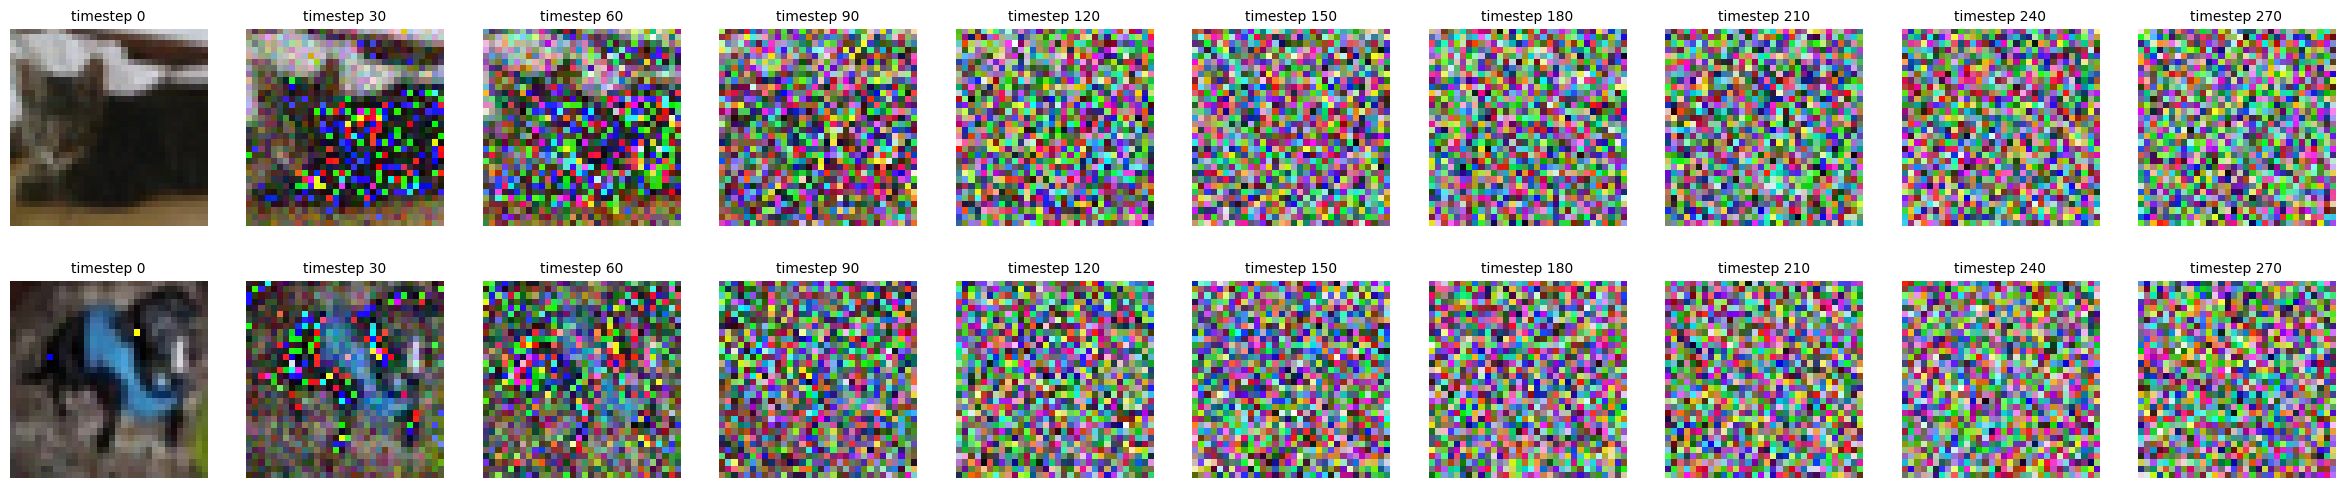

In [69]:
# Now let's test our model
# We can run the forward process again and visualize the output
# But now let's run it for 300 steps.

timesteps = 300
model = DiffusionModel(timesteps=timesteps, end_schedule=0.02, device=device)

plot_size = 10
step_size = timesteps // plot_size
f, axs = plt.subplots(2, plot_size, figsize = (plot_size*3,6))

for i in range(timesteps):
    if i % step_size != 0:
        continue
    k = i // step_size
    timestep = torch.tensor([i, i]).to(device)
    noisy_images, noise = model.forward(x0, timestep)
    for j, row in enumerate(axs):
        row[k].imshow(reverse_transform(noisy_images[j].cpu()))
        row[k].set_title(f"timestep {i}", fontsize = 10)
        row[k].axis("off")
plt.show()

# Part 3: Training a model to learn the data distribution of the noise

Now our goal is to train a model that can find the noise given a noisy image and we want to use this to undo the diffusion process

UNet is one model architecture that we can use. It will take the noisy image and learns to predict the noise (extract the noise from the noisy image).
This will be useful for the backward process.

**Note**  
We are not going to focus on UNet architecture (that is for a vision course probably). You can treat it as a black box here. We provide the code below. Just run this block and move on to the next blocks


In [70]:
# This creates the UNet architecture
# This is the model that we train to predict the added noise to each image
# You don't need to worry too much about how this is implemented.
# You can assume this is a black box model

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, channels_in, channels_out, time_embedding_dims, labels, num_filters = 3, downsample=True):
        super().__init__()

        self.time_embedding_dims = time_embedding_dims
        self.time_embedding = SinusoidalPositionEmbeddings(time_embedding_dims)
        self.labels = labels
        if labels:
            self.label_mlp = nn.Linear(1, channels_out)

        self.downsample = downsample

        if downsample:
            self.conv1 = nn.Conv2d(channels_in, channels_out, num_filters, padding=1)
            self.final = nn.Conv2d(channels_out, channels_out, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(2 * channels_in, channels_out, num_filters, padding=1)
            self.final = nn.ConvTranspose2d(channels_out, channels_out, 4, 2, 1)

        self.bnorm1 = nn.BatchNorm2d(channels_out)
        self.bnorm2 = nn.BatchNorm2d(channels_out)

        self.conv2 = nn.Conv2d(channels_out, channels_out, 3, padding=1)
        self.time_mlp = nn.Linear(time_embedding_dims, channels_out)
        self.relu = nn.ReLU()

    def forward(self, x, t, **kwargs):
        o = self.bnorm1(self.relu(self.conv1(x)))
        o_time = self.relu(self.time_mlp(self.time_embedding(t)))
        o = o + o_time[(..., ) + (None, ) * 2]
        if self.labels:
            label = kwargs.get('labels')
            o_label = self.relu(self.label_mlp(label))
            o = o + o_label[(..., ) + (None, ) * 2]

        o = self.bnorm2(self.relu(self.conv2(o)))

        return self.final(o)

class UNet(nn.Module):
    def __init__(self, img_channels = 3, time_embedding_dims = 128, labels = False, sequence_channels = (64, 128, 256, 512, 1024)):
        super().__init__()
        self.time_embedding_dims = time_embedding_dims
        sequence_channels_rev = reversed(sequence_channels)

        self.downsampling = nn.ModuleList([Block(channels_in, channels_out, time_embedding_dims, labels) for channels_in, channels_out in zip(sequence_channels, sequence_channels[1:])])
        self.upsampling = nn.ModuleList([Block(channels_in, channels_out, time_embedding_dims, labels,downsample=False) for channels_in, channels_out in zip(sequence_channels[::-1], sequence_channels[::-1][1:])])
        self.conv1 = nn.Conv2d(img_channels, sequence_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(sequence_channels[0], img_channels, 1)


    def forward(self, x, t, **kwargs):
        residuals = []
        o = self.conv1(x)
        for ds in self.downsampling:
            o = ds(o, t, **kwargs)
            residuals.append(o)
        for us, res in zip(self.upsampling, reversed(residuals)):
            o = us(torch.cat((o, res), dim=1), t, **kwargs)

        return self.conv2(o)

## Sampling code

#### Let's first remind ourselves of the algorithm for sampling after training the diffusion model

1. $ x_T \sim N(0, I) $
2. for $ t = T, \ldots, 1 $ do
3. &emsp;&emsp;$ z \sim N(0, I) $ if $ t > 1 $, else $ z = 0 $
4. &emsp;&emsp;$ x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_{\theta}(x_t, t) \right) + \sigma_t z $
5. end for
6. return $ x_0 $

Use this information to implement the backward process.
We will add another class that inherits from the original `DiffusionModel` class but also implements backward.

*Note* Complete the TODO parts


In [71]:
class DiffusionModelWithBackward(DiffusionModel):

    def __init__(self, start_schedule=0.0001, end_schedule=0.02, timesteps=300, device="cpu") -> None:
        super().__init__(start_schedule, end_schedule, timesteps, device)

    @torch.no_grad()
    def backward(self, x_t, t, model, noise=None):
        betas_t = self.get_index_from_list(self.betas, t, x_t.shape)

        sqrt_one_minus_alpha_comprod_t = self.get_index_from_list((1 - self.alpha_bar).sqrt(), t, x_t.shape)
        predicted_noise = model(x_t, t)

        one_over_sqrt_alpha = self.get_index_from_list((1 / self.alphas.sqrt()), t, x_t.shape)

        mean = one_over_sqrt_alpha * (
            x_t - betas_t / sqrt_one_minus_alpha_comprod_t * predicted_noise
        )

        posterior_variance_t = betas_t

        if t[0] == 0:
            return mean
        else:
            if noise is None:
                noise = torch.randn_like(x_t, device=self.device)
            variance = posterior_variance_t.sqrt() * noise
            return mean + variance

Recall the training process from the lecture:

## Training process

Repeat until converged:  
1- The first thing we do is sampling a batch from our image dataset
$x_0 \sim q(x_0)$

2- Then we sample a timestep  
$t \sim Uniform({1, ..., T})$  

3- Sample noise  
$\epsilon \sim N(0, 1)$  

4- Take a gradient descent step on:  
$\nabla_{\theta} \left\| \epsilon - \epsilon_0 \left( \sqrt{\hat{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \hat{\alpha}_t} \epsilon, t \right) \right\|^2$

Use this to implement the missing parts below:

Our goal is to overfit the model on a single example to see if our model can learn anything interesting.

Go through the following parts carefully and complete the `TODO` parts


In [72]:
loss_history = []
global_step  = 0

pbar = tqdm(total=n_epochs * len(dataloader), desc="Training")

for epoch in range(n_epochs):
    for x0, _ in dataloader:
        x0 = x0.to(device)
        bs = x0.shape[0]

        t = torch.randint(0, diffusion_model.timesteps, (bs,), device=device).long()
        noisy_image, ground_truth_noise = diffusion_model.forward(x0, t)
        predicted_noise = unet(noisy_image, t)

        loss = torch.nn.functional.mse_loss(predicted_noise, ground_truth_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step += 1
        loss_history.append(loss.item())

        if global_step % 50 == 0:
            pbar.set_postfix({"epoch": epoch+1, "loss": f"{loss.item():.4f}"})
            pbar.update(50)

pbar.close()
print(f"Training complete. Final loss: {loss_history[-1]:.4f}")

Training: 100%|██████████| 7800/7800 [03:15<00:00, 39.89it/s, epoch=100, loss=0.0444]

Training complete. Final loss: 0.0444


# Part 4: Sampling from the trained model

Now that we trained the model we want to run the backward on it to see what image we can get.
Since the model was trained on a single image, ideally it should be able to go back from noise to the original image it was trained on.  
Let's complete the missing parts specified by `TODO` below and see if the model can do this task effectively.


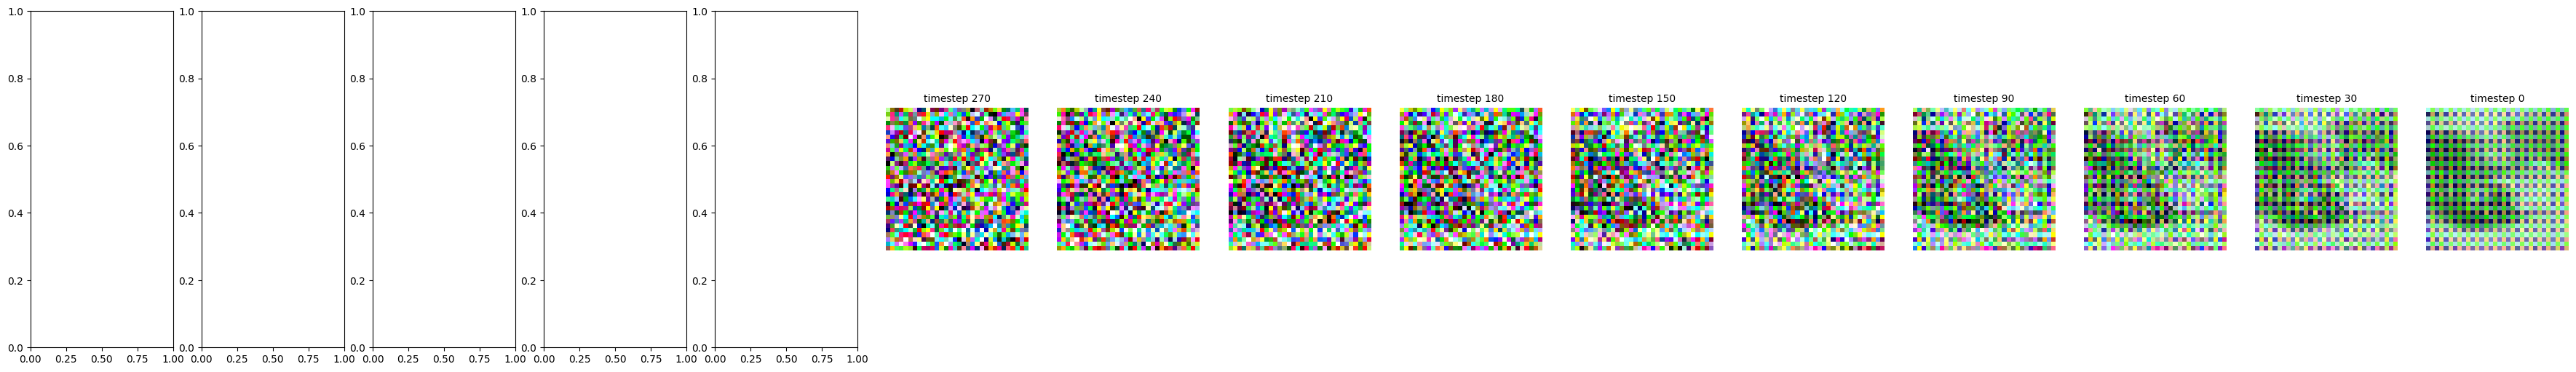

In [80]:
# some code for visualizaiton
large_steps = 10
timesteps = 300
step_size = timesteps // large_steps
plot_size = large_steps + 5
f, axs = plt.subplots(1, plot_size, figsize = (plot_size * 3,6))

# now let's check if the model can actually generate something starting from noise

# sample a noise
img = torch.randn([1, 3, 32, 32]).to(device)  # x_t at timestep 300

for i in reversed(range(diffusion_model.timesteps)):
    t = torch.full((1,), i, device=device, dtype=torch.long)
    img = diffusion_model.backward(img, t, unet)

    # The rest of the code for visualization
    if i % step_size != 0:
        continue
    k = i // step_size
    timestep = torch.tensor([i, i]).to(device)
    axs[plot_size - k - 1].imshow(reverse_transform(img[0].cpu()))
    axs[plot_size - k - 1].set_title(f"timestep {i}", fontsize = 10)
    axs[plot_size - k - 1].axis("off")
plt.show()

In [81]:
# Exponential Moving Average — smooths weights during training
class EMA:
    def __init__(self, model, decay=0.995):
        self.model = model
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self):
        for k, v in self.model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self):
        self.model.load_state_dict(self.shadow)

ema = EMA(unet, decay=0.995)
print("EMA ready")

EMA ready


In [82]:
extra_epochs = 400
pbar = tqdm(total=extra_epochs * len(dataloader), desc="Training (extended)")

for epoch in range(extra_epochs):
    for x0, _ in dataloader:
        x0 = x0.to(device)
        bs = x0.shape[0]

        t = torch.randint(0, diffusion_model.timesteps, (bs,), device=device).long()
        noisy_image, ground_truth_noise = diffusion_model.forward(x0, t)
        predicted_noise = unet(noisy_image, t)

        loss = torch.nn.functional.mse_loss(predicted_noise, ground_truth_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.update()

        loss_history.append(loss.item())
        global_step += 1

        if global_step % 50 == 0:
            pbar.set_postfix({"epoch": epoch+1, "loss": f"{loss.item():.4f}"})
            pbar.update(50)

pbar.close()
ema.apply()  # apply smoothed weights to unet
print(f"Done. Final loss: {loss_history[-1]:.4f}")

Training (extended): 100%|██████████| 31200/31200 [14:23<00:00, 36.12it/s, epoch=400, loss=0.0466]

Done. Final loss: 0.0466


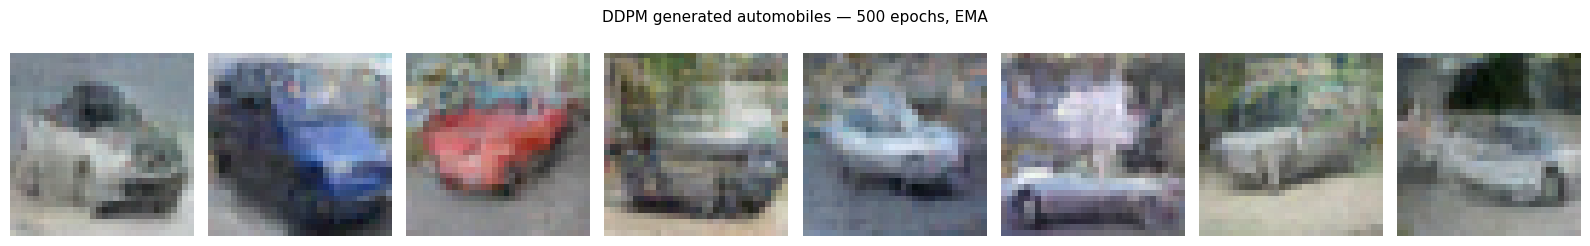

Saved: generated_images.png


In [83]:
@torch.no_grad()
def generate_grid(n=8):
    unet.eval()
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    for idx in range(n):
        img = torch.randn([1, 3, 32, 32], device=device)
        for i in reversed(range(diffusion_model.timesteps)):
            t = torch.full((1,), i, device=device, dtype=torch.long)
            img = diffusion_model.backward(img, t, unet)
        axes[idx].imshow(reverse_transform(img[0].cpu()))
        axes[idx].axis("off")
    plt.suptitle("DDPM generated automobiles — 500 epochs, EMA", fontsize=11)
    plt.tight_layout()
    plt.savefig("generated_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: generated_images.png")
    unet.train()

generate_grid(n=8)

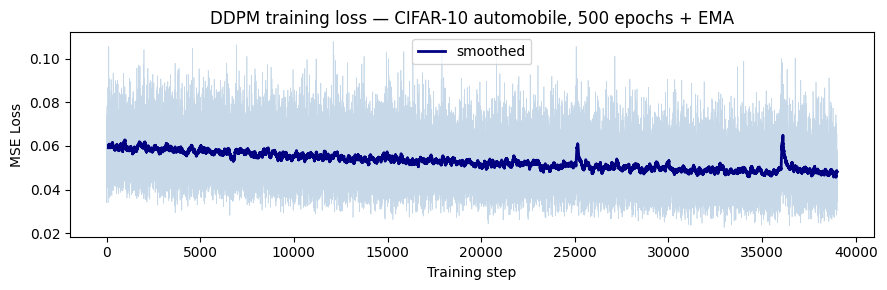

Saved: loss_curve.png


In [84]:
# Loss curve
import numpy as np
plt.figure(figsize=(9, 3))
plt.plot(loss_history, alpha=0.3, linewidth=0.5, color="steelblue")
smooth = np.convolve(loss_history, np.ones(100)/100, mode="valid")
plt.plot(range(99, len(loss_history)), smooth, linewidth=2, color="navy", label="smoothed")
plt.xlabel("Training step")
plt.ylabel("MSE Loss")
plt.title("DDPM training loss — CIFAR-10 automobile, 500 epochs + EMA")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_curve.png")

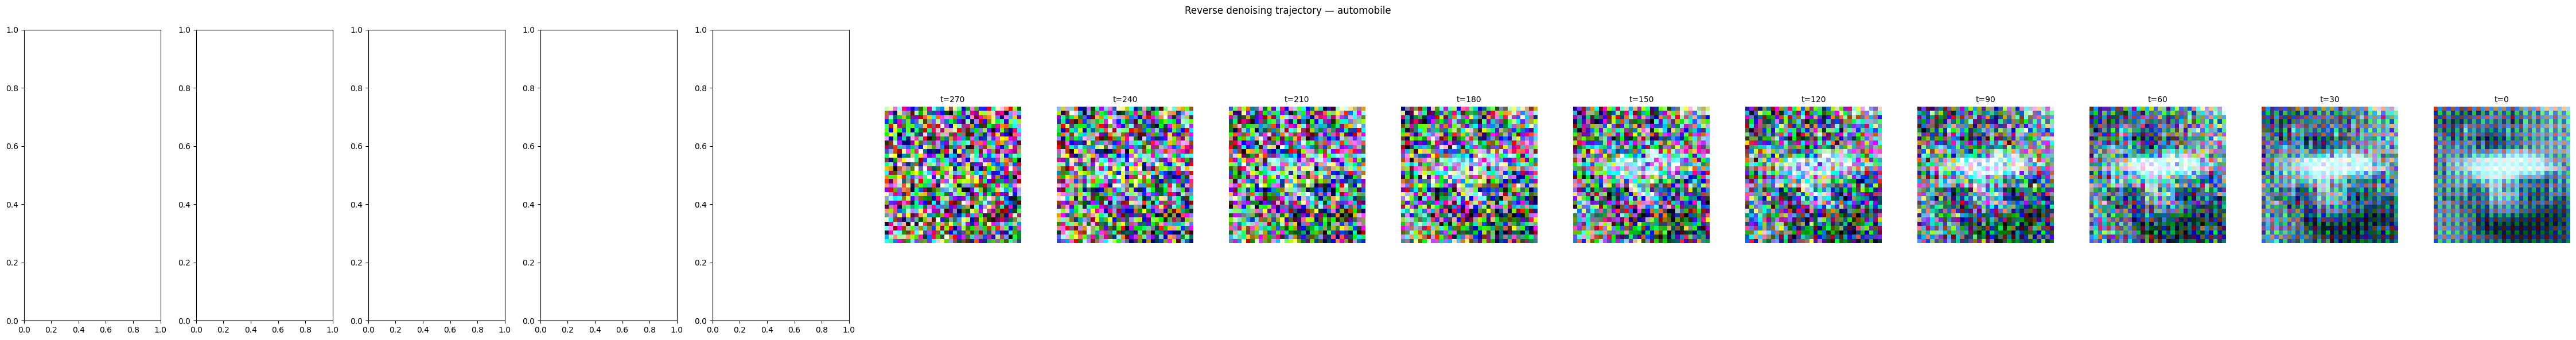

Saved: reverse_trajectory.png


In [85]:
# Trajectory
large_steps = 10
step_size = 300 // large_steps
plot_size = large_steps + 5
f, axs = plt.subplots(1, plot_size, figsize=(plot_size * 3, 6))

img = torch.randn([1, 3, 32, 32], device=device)
with torch.no_grad():
    for i in reversed(range(diffusion_model.timesteps)):
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = diffusion_model.backward(img, t, unet)
        if i % step_size != 0:
            continue
        k = i // step_size
        axs[plot_size - k - 1].imshow(reverse_transform(img[0].cpu()))
        axs[plot_size - k - 1].set_title(f"t={i}", fontsize=10)
        axs[plot_size - k - 1].axis("off")

plt.suptitle("Reverse denoising trajectory — automobile", fontsize=12)
plt.tight_layout()
plt.savefig("reverse_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reverse_trajectory.png")